<a href="https://colab.research.google.com/github/adishup/gen-ai-lab/blob/main/experiment%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers torch pillow matplotlib

EXPERIMENT 10 - MULTIMODAL AI

GPU not available.
Using CPU.

Loading BLIP processor...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

BLIP model loaded successfully.

UPLOAD IMAGE

Choose an image from your computer.


Saving munnar images.png to munnar images.png

Uploaded file:
munnar images.png


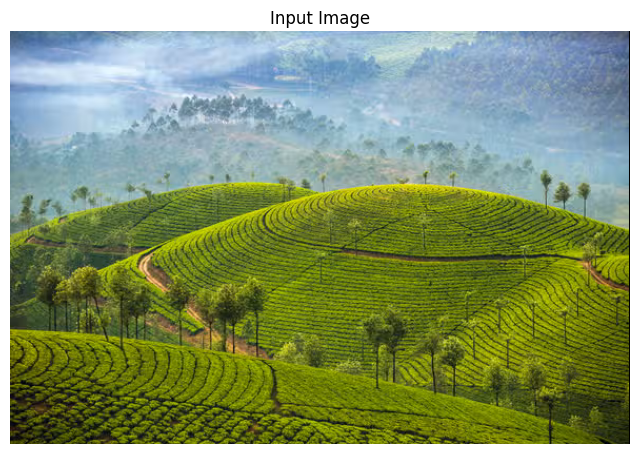


ASK QUESTION

Enter a question about the image: what this hill station famous for?

Analyzing image...

MULTIMODAL AI RESULT

Question:
what this hill station famous for?

Answer:
vietnam

EXPERIMENT 10 COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================
# EXPERIMENT 10
# MULTIMODAL AI - VISUAL QUESTION ANSWERING USING BLIP
# ============================================================

import torch
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

from transformers import (
    BlipProcessor,
    BlipForQuestionAnswering
)


print("=" * 60)
print("EXPERIMENT 10 - MULTIMODAL AI")
print("=" * 60)


# ============================================================
# 1. SELECT DEVICE
# ============================================================

if torch.cuda.is_available():

    device = torch.device("cuda")

    print("\nGPU Available")
    print("GPU:", torch.cuda.get_device_name(0))

else:

    device = torch.device("cpu")

    print("\nGPU not available.")
    print("Using CPU.")


# ============================================================
# 2. LOAD BLIP PROCESSOR
# ============================================================

model_name = "Salesforce/blip-vqa-base"

print("\nLoading BLIP processor...")

processor = BlipProcessor.from_pretrained(
    model_name
)

print("Processor loaded successfully.")


# ============================================================
# 3. LOAD BLIP MODEL
# ============================================================

print("\nLoading BLIP VQA model...")

model = BlipForQuestionAnswering.from_pretrained(
    model_name
)

model = model.to(device)

model.eval()

print("BLIP model loaded successfully.")


# ============================================================
# 4. UPLOAD IMAGE
# ============================================================

print("\n" + "=" * 60)
print("UPLOAD IMAGE")
print("=" * 60)

print("\nChoose an image from your computer.")

uploaded = files.upload()


# Get uploaded image filename

image_filename = next(
    iter(uploaded)
)


print("\nUploaded file:")
print(image_filename)


# ============================================================
# 5. OPEN IMAGE
# ============================================================

image = Image.open(
    image_filename
).convert("RGB")


# ============================================================
# 6. DISPLAY IMAGE
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.imshow(image)

plt.axis("off")

plt.title("Input Image")

plt.show()


# ============================================================
# 7. ENTER QUESTION
# ============================================================

print("\n" + "=" * 60)
print("ASK QUESTION")
print("=" * 60)


question = input(
    "\nEnter a question about the image: "
)


# ============================================================
# 8. PROCESS IMAGE + QUESTION
# ============================================================

inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
)


# Move tensors to GPU/CPU

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


# ============================================================
# 9. GENERATE ANSWER
# ============================================================

print("\nAnalyzing image...")

with torch.no_grad():

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=30
    )


# ============================================================
# 10. DECODE ANSWER
# ============================================================

answer = processor.decode(
    generated_ids[0],
    skip_special_tokens=True
)


# ============================================================
# 11. DISPLAY RESULT
# ============================================================

print("\n" + "=" * 60)
print("MULTIMODAL AI RESULT")
print("=" * 60)

print("\nQuestion:")
print(question)

print("\nAnswer:")
print(answer)


# ============================================================
# 12. COMPLETION
# ============================================================

print("\n" + "=" * 60)
print("EXPERIMENT 10 COMPLETED SUCCESSFULLY")
print("=" * 60)